# test_heater_02_0d_1d_cstr_prf — 0D/1D · Batch/Flow

Four canonical operating modes to verify physical consistency:

| Case | N | v_in | Description |
|------|---|------|-------------|
| 0D-Batch | 1 | 0 | Sealed tube; isochoric: P/P0 = T/T0 |
| 1D-Batch | 21 | 0 | Distributed sealed tube; uniform Tg profile |
| 0D-CSTR | 1 | >0 | Well-mixed; DeltaT_ss = Q/(mdot*Cp) |
| 1D-PRF | 21 | >0 | Plug-flow; axial gradient develops |

Heat source: `heatfluxwall`, Q_WALL=10W.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.units.heater.config.gas_props  import build_gas_prop_config
from src.units.heater.config.boundary_c import build_boundary_c_config
from src.units.heater.config.thermal_bc import build_thermal_bc_config
from src.units.heater.config.transport  import build_transport_config
from src.units.heater.config.initial_c  import build_initial_c_config
from src.units.heater.state             import pack_state_vector
from src.solvers.runner_heater          import run_step

ROOT   = os.path.abspath('..')
DB_GAS = os.path.join(ROOT, 'materials', 'fluids', 'gasdb.txt')
print('Imports OK')

Imports OK


In [2]:
# ── Common parameters ─────────────────────────────────────────────────────────
L      = 0.5        # m
Di     = 0.05       # m
Do     = 0.056      # m
e_wall = (Do - Di) / 2.0
Ai     = 0.25 * np.pi * Di**2
Pi     = np.pi * Di
Po     = np.pi * Do

nc      = 1
SPECIES = ['N2']

T_INIT  = 300.0     # K
T_IN    = 300.0     # K  inlet (used in flow cases)
P_INIT  = 1.01325   # bar
P_OUT   = 1.01325   # bar

Q_WALL = 10.0       # W
V_FLOW = 0.1        # m/s
T_MAX  = 120.0      # s

print(f'Tube: L={L}m  Di={Di}m  Ai={Ai*1e4:.3f}cm2')

Tube: L=0.5m  Di=0.05m  Ai=19.635cm2


In [3]:
# ── Helper: build and run for given (n_cells, v_in) ──────────────────────────
def run_heater(n_cells, v_in):
    dz_loc = L / n_cells

    pg  = build_gas_prop_config(species=SPECIES, mode='polynomial',
                                 n_comp=nc, N=n_cells, T_ref=T_INIT, db_path=DB_GAS)
    g_ref = float(np.min(np.asarray(pg['Tref'])))

    bc  = build_boundary_c_config(n_comp=nc, v_in=v_in, T_in=T_IN,
                                   y_in=np.array([1.0]), P_out=P_OUT)
    tbc = build_thermal_bc_config(mode='heatfluxwall', Di=Di, Do=Do,
                                   e_wall=e_wall, Qwall=Q_WALL)
    tr  = build_transport_config(mode='correlation', N=n_cells)

    y0  = np.ones((nc, n_cells), dtype=float)
    P0  = np.full(n_cells, P_INIT)
    T0  = np.full(n_cells, T_INIT)
    ic  = build_initial_c_config(P_init=P0, Tg_init=T0, y_init=y0,
                                  n_comp=nc, N=n_cells, prop_gas=pg, gas_T_ref=g_ref)
    sv0 = pack_state_vector(C=ic['C_init'], Hg=ic['Hg_init'])

    params = dict(
        n_comp=nc, N=n_cells, dz=dz_loc, Ai=Ai, Di=Di, Pi=Pi, Po=Po,
        prop_gas=pg, MW=np.asarray(pg['MW']),
        gas_T_ref=g_ref,
        bc_config=bc, trans_config=tr, thermal_bc_config=tbc,
        energy=True, prop_update_mode='always', trans_update_mode='always',
        species=SPECIES, _cache={},
    )

    t0 = time.perf_counter()
    _, _, heater = run_step(sv0=sv0, t_max=T_MAX, params=params,
                             solver='solve_ivp', rtol=1e-7, atol=1e-9, n_sec=5)
    cpu = time.perf_counter() - t0
    return heater, cpu

print('Helper OK')

Helper OK


## Case 1 — 0D Batch (N=1, v=0)

In [4]:
h1, cpu1 = run_heater(n_cells=1, v_in=0.0)

Tg1 = float(h1._Tg_results[-1, 0])
P1  = float(h1._P_results[-1, 0])

# Isochoric ideal gas: P/P0 = T/T0 (Ctot constant since dC/dt=0 with v=0)
P1_exp = P_INIT * Tg1 / T_INIT
print(f'0D-Batch: Tg = {Tg1:.4f} K   P = {P1:.5f} bar')
print(f'  Expected P = {P1_exp:.5f} bar   ratio T/T0 = {Tg1/T_INIT:.5f}')

assert Tg1 > T_INIT + 0.5, f'0D-Batch: gas must heat up, got Tg={Tg1:.4f}K'
err_P = abs(P1 - P1_exp) / P1_exp
assert err_P < 0.01, f'0D-Batch: P/P0 != T/T0, relative error = {err_P:.4f}'
print(f'  Isochoric P check OK  (error={err_P*100:.3f}%)  CPU={cpu1:.1f}s')

0D-Batch: Tg = 1259.7902 K   P = 4.25494 bar
  Expected P = 4.25494 bar   ratio T/T0 = 4.19930
  Isochoric P check OK  (error=0.000%)  CPU=0.7s


## Case 2 — 1D Batch (N=21, v=0)

In [5]:
h2, cpu2 = run_heater(n_cells=21, v_in=0.0)

Tg2      = h2._Tg_results[-1]
dT_axial = float(Tg2.max() - Tg2.min())

print(f'1D-Batch: mean Tg = {Tg2.mean():.4f} K   axial spread = {dT_axial:.4f} K')
print(f'  0D-Batch Tg = {Tg1:.4f} K')

# Same total energy input into same total gas mass => mean temperatures must match
assert abs(Tg2.mean() - Tg1) < 2.0, \
    f'1D vs 0D batch mean Tg: {Tg2.mean():.4f} vs {Tg1:.4f}'
# v=0 => no convection => axial profile must be nearly flat
assert dT_axial < 5.0, f'1D-Batch axial spread too large: {dT_axial:.4f} K'
print(f'  Mean match OK, profile flat OK  CPU={cpu2:.1f}s')

1D-Batch: mean Tg = 1259.7902 K   axial spread = 0.0000 K
  0D-Batch Tg = 1259.7902 K
  Mean match OK, profile flat OK  CPU=2.1s


## Case 3 — 0D CSTR (N=1, v>0)

In [6]:
h3, cpu3 = run_heater(n_cells=1, v_in=V_FLOW)

Tg3 = float(h3._Tg_results[-1, 0])

# Steady-state energy balance: Q = mdot * Cp_mass * DeltaT
# Use ideal gas properties at inlet conditions
R_gas  = 8.31446
MW_N2  = 0.028          # kg/mol
rho_in = (P_INIT * 1e5) * MW_N2 / (R_gas * T_IN)
Cp_N2  = 1040.0         # J/kg/K  approx at 300 K
mdot   = rho_in * V_FLOW * Ai
DT_ss  = Q_WALL / (mdot * Cp_N2)

print(f'0D-CSTR: Tg_final = {Tg3:.4f} K   (T_IN = {T_IN:.1f} K)')
print(f'  Energy balance: DeltaT_ss = {DT_ss:.4f} K  =>  Tg_ss = {T_IN+DT_ss:.4f} K')
print(f'  rho_in={rho_in:.4f} kg/m3  mdot={mdot*1000:.4f} g/s')

assert Tg3 > T_IN + 0.5, f'0D-CSTR: gas must heat above inlet, got {Tg3:.4f}K'
# Tolerance 30%: Cp approximation + system may not be fully at steady state at t=T_MAX
err_T = abs(Tg3 - (T_IN + DT_ss))
tol_T = 0.30 * DT_ss
assert err_T < tol_T, \
    f'0D-CSTR energy balance: DeltaT_got={Tg3-T_IN:.4f} vs DeltaT_ss={DT_ss:.4f} (tol={tol_T:.4f})'
print(f'  Energy balance check OK  (error={err_T:.4f}K, tol={tol_T:.4f}K)  CPU={cpu3:.1f}s')

0D-CSTR: Tg_final = 338.0611 K   (T_IN = 300.0 K)
  Energy balance: DeltaT_ss = 43.0544 K  =>  Tg_ss = 343.0544 K
  rho_in=1.1374 kg/m3  mdot=0.2233 g/s
  Energy balance check OK  (error=4.9933K, tol=12.9163K)  CPU=0.8s


## Case 4 — 1D PRF (N=21, v>0)

In [7]:
h4, cpu4 = run_heater(n_cells=21, v_in=V_FLOW)

Tg4 = h4._Tg_results[-1]

# Plug-flow: temperature rises monotonically from inlet to outlet
assert Tg4[-1] > Tg4[0] + 0.5, f'1D-PRF: outlet must be hotter than inlet'
assert np.all(np.diff(Tg4) >= -0.5), '1D-PRF: temperature must be non-decreasing axially'

# PRF outlet temperature should be close to CSTR at steady state
# (same total energy balance Q = mdot*Cp*DeltaT applies to both)
print(f'1D-PRF:  Tg_in={Tg4[0]:.4f}K   Tg_out={Tg4[-1]:.4f}K')
print(f'0D-CSTR: Tg_out={Tg3:.4f}K')
err_cstr = abs(Tg4[-1] - Tg3)
assert err_cstr < 5.0, f'1D-PRF outlet vs 0D-CSTR: error={err_cstr:.4f}K > 5K'
print(f'  PRF outlet ~ CSTR OK  (diff={err_cstr:.4f}K)  CPU={cpu4:.1f}s')

1D-PRF:  Tg_in=302.0113K   Tg_out=342.6050K
0D-CSTR: Tg_out=338.0611K
  PRF outlet ~ CSTR OK  (diff=4.5439K)  CPU=1.4s


## Summary table

In [8]:
rows = [
    dict(case='0D-Batch', N=1,  v_in=0.0,    Tg_K=round(Tg1,4),              P_bar=round(h1._P_results[-1,0],5), cpu_s=round(cpu1,1)),
    dict(case='1D-Batch', N=21, v_in=0.0,    Tg_K=round(float(h2._Tg_results[-1].mean()),4), P_bar=round(float(h2._P_results[-1].mean()),5), cpu_s=round(cpu2,1)),
    dict(case='0D-CSTR',  N=1,  v_in=V_FLOW, Tg_K=round(Tg3,4),              P_bar=round(h3._P_results[-1,0],5), cpu_s=round(cpu3,1)),
    dict(case='1D-PRF',   N=21, v_in=V_FLOW, Tg_K=round(float(h4._Tg_results[-1].mean()),4), P_bar=round(float(h4._P_results[-1].mean()),5), cpu_s=round(cpu4,1)),
]
df = pd.DataFrame(rows).set_index('case')
print(df.to_string())
print('\nAll assertions passed  OK')

           N  v_in       Tg_K    P_bar  cpu_s
case                                         
0D-Batch   1   0.0  1259.7902  4.25494    0.7
1D-Batch  21   0.0  1259.7902  4.25494    2.1
0D-CSTR    1   0.1   338.0611  1.14180    0.8
1D-PRF    21   0.1   322.3153  1.08862    1.4

All assertions passed  OK


## Comparison plots

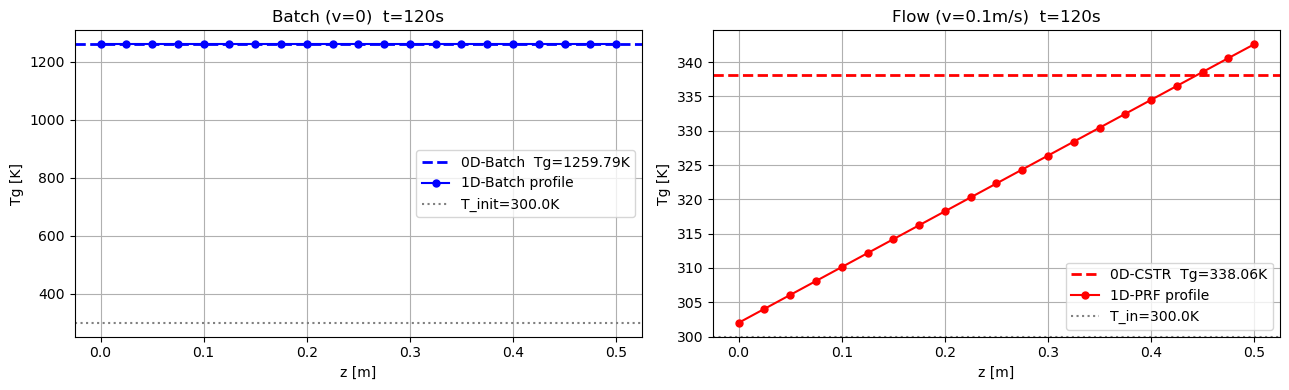

In [9]:
z21 = np.linspace(0, L, 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.axhline(Tg1, color='blue', ls='--', lw=2, label=f'0D-Batch  Tg={Tg1:.2f}K')
ax.plot(z21, h2._Tg_results[-1], 'b-o', ms=5, label='1D-Batch profile')
ax.axhline(T_INIT, color='gray', ls=':', label=f'T_init={T_INIT}K')
ax.set_xlabel('z [m]'); ax.set_ylabel('Tg [K]')
ax.set_title(f'Batch (v=0)  t={T_MAX:.0f}s')
ax.legend(); ax.grid(True)

ax = axes[1]
ax.axhline(Tg3, color='red', ls='--', lw=2, label=f'0D-CSTR  Tg={Tg3:.2f}K')
ax.plot(z21, h4._Tg_results[-1], 'r-o', ms=5, label='1D-PRF profile')
ax.axhline(T_IN, color='gray', ls=':', label=f'T_in={T_IN}K')
ax.set_xlabel('z [m]'); ax.set_ylabel('Tg [K]')
ax.set_title(f'Flow (v={V_FLOW}m/s)  t={T_MAX:.0f}s')
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

## Pressure check (Batch)

In [24]:
print('Batch pressure (isochoric: P/P0 = T/T0):')
print(f'  0D-Batch: P={h1._P_results[-1,0]:.5f}bar  T/T0={Tg1/T_INIT:.5f}  P/P0={h1._P_results[-1,0]/P_INIT:.5f}')
P2_mean = float(h2._P_results[-1].mean())
T2_mean = float(h2._Tg_results[-1].mean())
print(f'  1D-Batch: P={P2_mean:.5f}bar  T/T0={T2_mean/T_INIT:.5f}  P/P0={P2_mean/P_INIT:.5f}')
print()
print('Flow pressure (open system, P~const):')
print(f'  0D-CSTR: P={h3._P_results[-1,0]:.5f}bar')
print(f'  1D-PRF:  P_mean={float(h4._P_results[-1].mean()):.5f}bar')

Batch pressure (isochoric: P/P0 = T/T0):
  0D-Batch: P=4.18391bar  T/T0=4.12920  P/P0=4.12920
  1D-Batch: P=3.95857bar  T/T0=3.90681  P/P0=3.90681

Flow pressure (open system, P~const):
  0D-CSTR: P=1.14180bar
  1D-PRF:  P_mean=1.08862bar
